# Interaction — clipping, slicing, thresholding and picking

These live **below the figure seam**: each attaches a PyVista widget or picker to the render window and
returns its handle, leaving the declarative figure unchanged. They are meant for a *live* window
(`serve()` or `jupyter()`, notebook 16) — here, headless, we construct each and screenshot the result so
the API is clear. Each mesh widget hides the plain layer it acts on so nothing overdraws.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from digitalearth.base.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

## `clip_plane()` — cut the mesh with a draggable plane

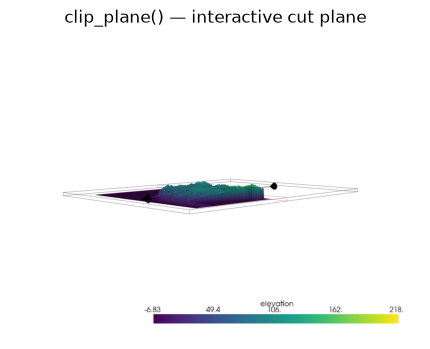

In [2]:
from pyramids.dataset import Dataset
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain', name='dem')
scene.clip_plane('dem', normal=(1, 0, 0))
show(scene, 'clip_plane() — interactive cut plane')
scene.close()

## `clip_box()` — cut with a draggable box

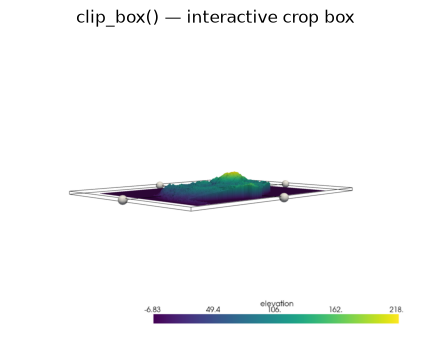

In [3]:
from pyramids.dataset import Dataset
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain', name='dem')
scene.clip_box('dem')
show(scene, 'clip_box() — interactive crop box')
scene.close()

## `threshold()` — keep cells inside a value range

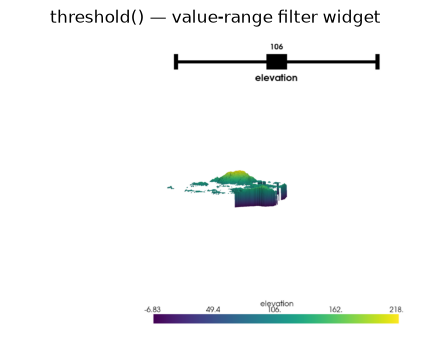

In [4]:
from pyramids.dataset import Dataset
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='viridis', name='dem')
scene.threshold('dem')
show(scene, 'threshold() — value-range filter widget')
scene.close()

## `isovalue()` — a moving contour

Contours the layer's active scalar (point data — a terrain surface works; a ray-cast volume does not).

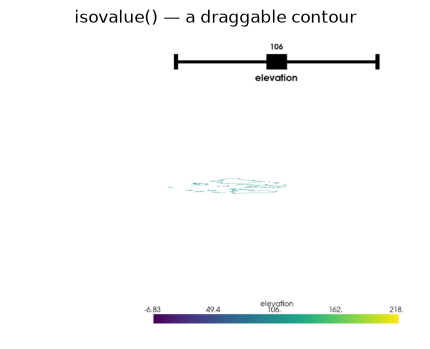

In [5]:
from pyramids.dataset import Dataset
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='plasma', name='dem')
scene.isovalue('dem')
show(scene, 'isovalue() — a draggable contour')
scene.close()

## `slider()` — drive a parameter from a callback

The callback runs on every slider move in a live window; here we just construct it.

slider handle: vtkSliderWidget


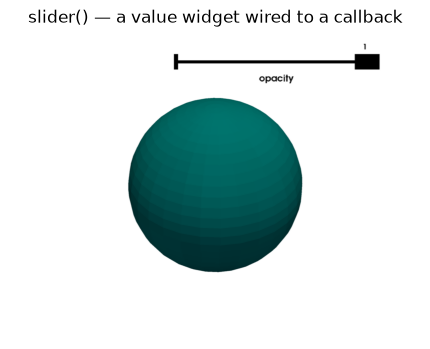

In [6]:
scene = Scene3D(off_screen=True)
scene.add_mesh(pv.Sphere(), color='teal', name='ball')

def on_change(value):
    scene.actor_of('ball').prop.opacity = value

handle = scene.slider(on_change, (0.0, 1.0), value=1.0, title='opacity')
print('slider handle:', type(handle).__name__)
show(scene, 'slider() — a value widget wired to a callback')
scene.close()

## Picking — identify the layer under the cursor

`enable_picking()` installs a picker; after a click in a live window `picked_layer()` returns the layer id. Headless there is no click, so it is `None`.

In [7]:
scene = Scene3D(off_screen=True)
scene.add_mesh(pv.Cube(), name='box')
scene.enable_picking(mode='point')
print('picked so far:', scene.picked_layer())   # None — nothing clicked headless
scene.disable_picking()
print('picking disabled')
scene.close()

picked so far: None
picking disabled
